In [59]:
from pandas import read_excel, to_numeric,ExcelFile
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [60]:
dfs = {}

for archivo in Path("data/rc_data").glob("*.xls"):

    with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
        primera = f.readline().strip()

    dfs[archivo.stem] = read_excel(
    archivo,
    sheet_name="Sheet1",
    engine="xlrd",
    header=None
)

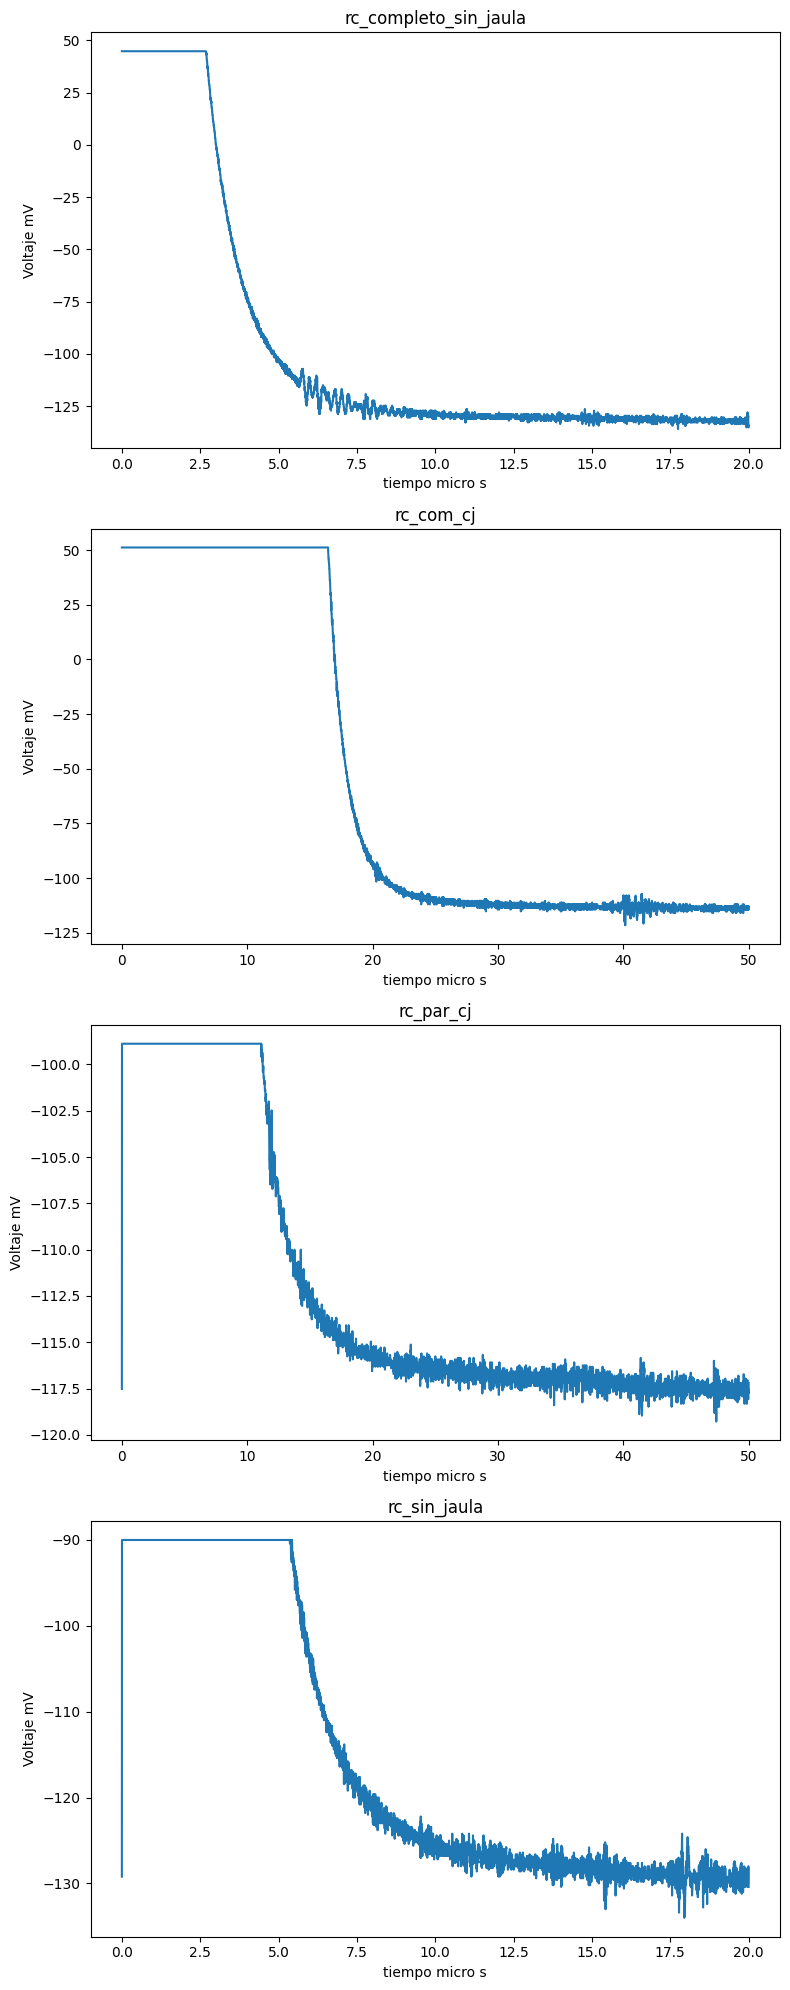

In [61]:
n = int(len(dfs)/2)
fig, ax = plt.subplots(n,1, figsize = (8,20))

i = 0

t_rc = []
f_rc = []

for clave, df in dfs.items():
   delta_t = to_numeric(df.iloc[5,1].replace("uS", "").strip())

   if i%2 == 0:

      t1 = (
         df.iloc[10:,0]*delta_t
      ).to_numpy()

      f1 = (
         df.iloc[10:,1]
      ).to_numpy()
   else:
      k= int(i / 2)
      t2 = (
         df.iloc[10:,0]*delta_t
      ).to_numpy()

      f2 = (
         df.iloc[10:,1]
      ).to_numpy()

      t =np.concatenate((t1,t2), axis = 0)
      f =np.concatenate((f1,f2), axis = 0)
      
      t_rc.append(t)
      f_rc.append(f)

      clave = clave.replace("_2", "")
      ax[k].set_title(clave)
      ax[k].set_xlabel('tiempo micro s')
      ax[k].set_ylabel('Voltaje mV')
      ax[k].plot(t,f)
   i+=1
# Ajustar el espaciado entre subplots
plt.tight_layout()
plt.show()


In [62]:
t_is = np.array([2.5,17,13,5.5]) #array con los valores desde los cuales se iniciara a analizar cada base de datos
cant = 500 # numero de intervalos al que se le va a sacar el voltaje promedio
n = len(f_rc) # extraemos la cantidad de bases de datos
V_rc = [] #Creamos una lista para almacenar los voltajes promedios de cada base
inVrc = []
# con este ciclo recorremos cada base de datos
for i in range(n):
    rci = f_rc[i] #extraemos la iesima base de datos
    trci = t_rc[i] #extraemos la iesima base de datos de tiempo

    ti = t_is[i] #tiempo inicial
    m = len(rci) # extraemos el numero de elementos de esa base
    paso = int(m/cant) #calculamos el paso para calcular el promedio

    jant = 0 #inicializamos el contador anterior en cero

    V_rci = []# creamos una lista para almacenar los promedios de cada base de datos

    inVrci = []
    #con este ciclo recorremos la base de datos para extraer los promedios por intervalos
    for j in range(paso, m, paso):
        #aplicamos la condicion de el tiempo inicial
        if trci[jant]>= ti :
            rcj = np.power(rci[jant: j]*1e-3,2)
            prom = np.mean(rcj) #extraemos el promedio por intervalo

            V_rci.append(prom) # se guarda en la lista
            inVrci.append(np.std(rcj)/np.sqrt(paso))
        #se actualizan los contadores
        jant = j
    inVrc.append(inVrci)
    V_rc.append(V_rci)# se guardan los promedios de las bases de datos en la lista


    

In [63]:
V_rc

[[np.float64(0.002007040059814454),
  np.float64(0.002007040059814454),
  np.float64(0.002007040059814454),
  np.float64(0.002007040059814454),
  np.float64(0.0018003840536556244),
  np.float64(0.001319712039330483),
  np.float64(0.0009151040272722247),
  np.float64(0.0005816000173330309),
  np.float64(0.00036160001077651993),
  np.float64(0.00017900800533485417),
  np.float64(7.392000220298767e-05),
  np.float64(1.3696000408172613e-05),
  np.float64(2.9760000886917124e-06),
  np.float64(3.321600098991395e-05),
  np.float64(0.00010812800322246554),
  np.float64(0.0002055040061244965),
  np.float64(0.0003463040103206635),
  np.float64(0.00046854401396369955),
  np.float64(0.0006696320199565891),
  np.float64(0.0008421440250978472),
  np.float64(0.0010743360320177085),
  np.float64(0.0013056320389108662),
  np.float64(0.001506944044910431),
  np.float64(0.0017518080522079473),
  np.float64(0.0020331200605916986),
  np.float64(0.002275968067829132),
  np.float64(0.0025626560763731014),
  

In [64]:
dfs = {}

for archivo in Path("data/rlc_data").glob("*.xls"):

    xls = ExcelFile(archivo, engine="xlrd")

    # tomar la primera hoja disponible
    sheet = xls.sheet_names[0]

    dfs[archivo.stem] = read_excel(
        archivo,
        sheet_name=sheet,
        engine="xlrd",
        header=None
    )

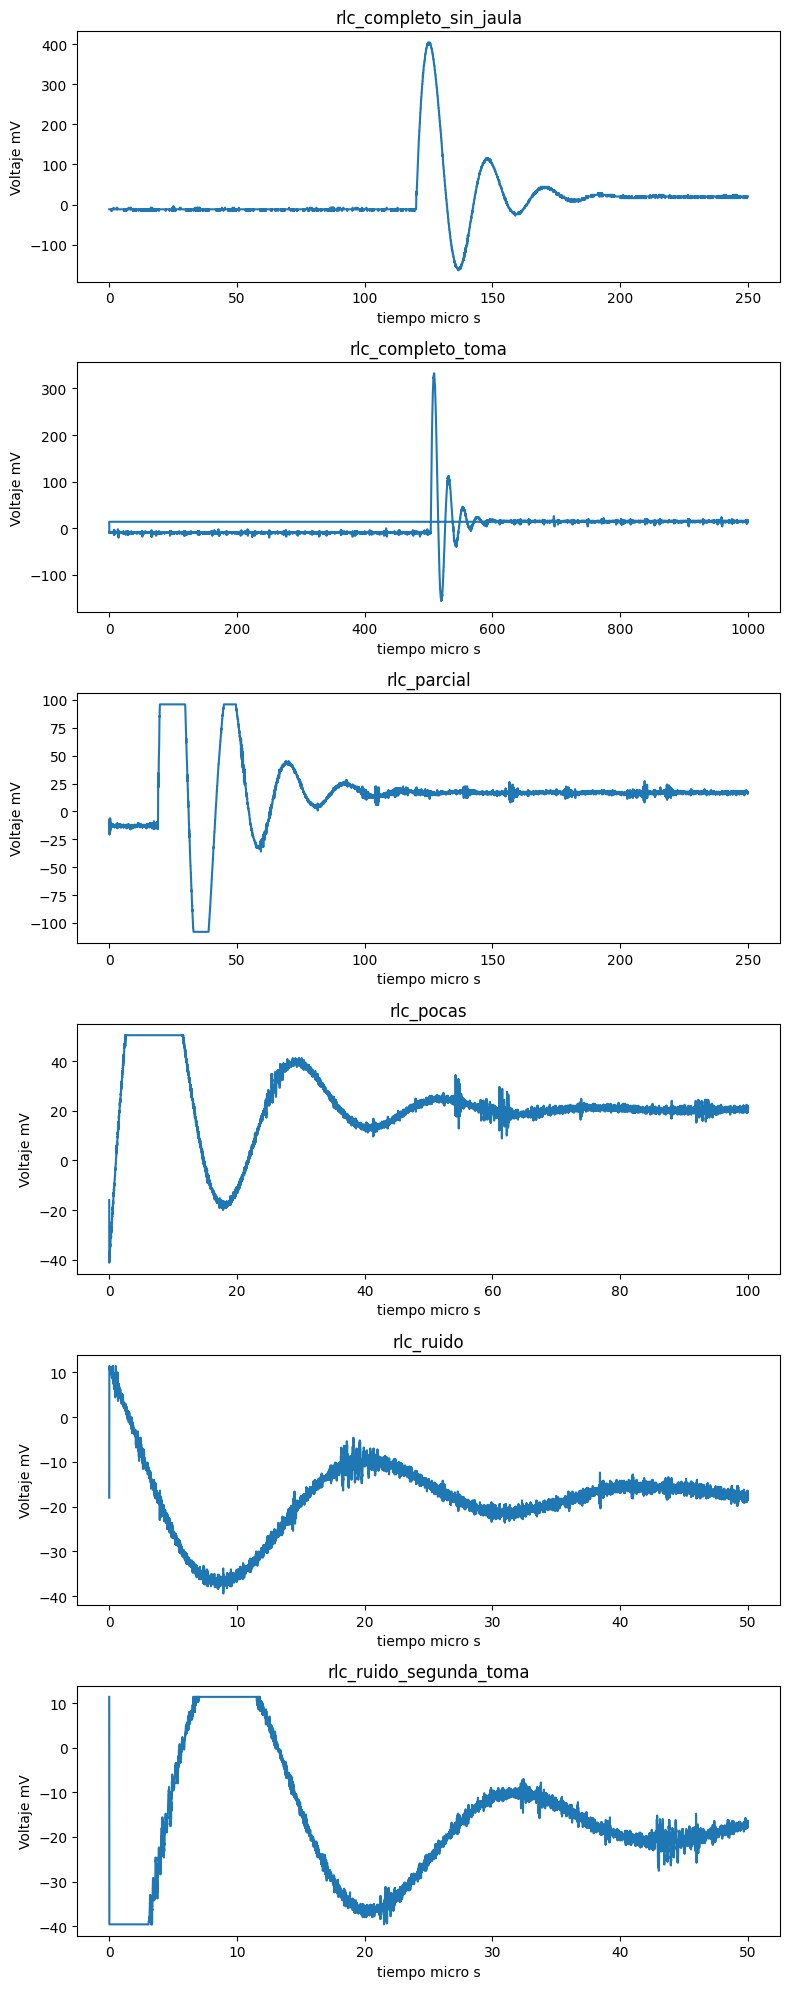

In [65]:
n = int(len(dfs)/2)
fig, ax = plt.subplots(n,1, figsize = (8,20))

t_rlc = []
f_rlc = []

i = 0
for clave, df in dfs.items():
   delta_t = to_numeric(df.iloc[5,1].replace("uS", "").strip().replace(",", "."))

   if i%2 == 0:

      t1 = (
         df.iloc[10:,0]*delta_t
      ).to_numpy()

      f1 = (
         df.iloc[10:,1]
      ).to_numpy()
   else:
      k= int(i / 2)
      t2 = (
         df.iloc[10:,0]*delta_t
      ).to_numpy()

      f2 = (
         df.iloc[10:,1]
      ).to_numpy()

      t =np.concatenate((t1,t2), axis = 0)
      f =np.concatenate((f1,f2), axis = 0)

      t_rlc.append(t)
      f_rlc.append(f)
      clave = clave.replace("_2", "")
      ax[k].set_title(clave)
      ax[k].set_xlabel('tiempo micro s')
      ax[k].set_ylabel('Voltaje mV')
      ax[k].plot(t,f)
   i+=1
# Ajustar el espaciado entre subplots
plt.tight_layout()
plt.show()


In [66]:
cant = 100 # numero de intervalos al que se le va a sacar el voltaje promedio
t_is1 = np.array([120, 500, 50 ,15,0,12]) #array con los valores desde los cuales se iniciara a analizar cada base de datos
n = len(f_rlc) # extraemos la cantidad de bases de datos
V_rlc = [] #Creamos una lista para almacenar los voltajes promedios de cada base
inVrlc = []
# con este ciclo recorremos cada base de datos
for i in range(n):
    rlci = f_rlc[i] #extraemos la iesima base de datos
    trlci = t_rlc[i] #extraemos la iesima base de datos de tiempo

    ti = t_is1[i] #tiempo inicial
    m = len(rlci) # extraemos el numero de elementos de esa base
    paso = int(m/cant) #calculamos el paso para calcular el promedio

    jant = 0 #inicializamos el contador anterior en cero

    V_rlci = []# creamos un array para almacenar los promedios de cada base de datos
    inVrlci = []
    #con este ciclo recorremosnla base de datos para extraer los promedios por intervalos
    for j in range(paso, m, paso):
        #aplicamos la condicion de el tiempo inicial
        if trlci[jant]>=ti:
            rlcj = np.power(rlci[jant: j]*1e-3,2)
            prom = np.mean(rlcj) #extraemos el promedio por intervalo

            V_rlci.append(prom) # se guarda en el array
            inVrlci.append(np.std(rlcj)/np.sqrt(paso))     
        #se actualizan los contadores
        jant = j

    V_rlc.append(V_rlci)# se guardan los promedios de las bases de datos en la lista
    inVrlc.append(inVrlci)

    

In [67]:
V_rlc

[[np.float64(0.03373983999999999),
  np.float64(0.13644639999999997),
  np.float64(0.14481855999999996),
  np.float64(0.06508655999999995),
  np.float64(0.006798240000000002),
  np.float64(0.009226719999999992),
  np.float64(0.024392000000000004),
  np.float64(0.017384639999999982),
  np.float64(0.0031596799999999998),
  np.float64(0.0022611199999999997),
  np.float64(0.009924000000000006),
  np.float64(0.011907840000000001),
  np.float64(0.0064540799999999975),
  np.float64(0.0013692800000000011),
  np.float64(9.727999999999994e-05),
  np.float64(0.00051184),
  np.float64(0.0003131199999999998),
  np.float64(6.592e-05),
  np.float64(0.0007078399999999994),
  np.float64(0.0016391999999999976),
  np.float64(0.0018086399999999953),
  np.float64(0.0012187199999999997),
  np.float64(0.0005326399999999992),
  np.float64(0.00020303999999999944),
  np.float64(9.919999999999993e-05),
  np.float64(0.000132),
  np.float64(0.00026335999999999986),
  np.float64(0.00047920000000000005),
  np.float6

In [68]:
def calculo_boltzmanrc(Vp_2, T, C):
    return Vp_2* C/ T
constantrc = []
in_constrc = []
for i in range(len(V_rc)):
    n = len(V_rc[i])
    for j in range(n):
        Vp = V_rc[i][j]
        inVp = inVrc[i][j]
        constantrc.append(calculo_boltzmanrc(Vp, 293, 1e-9))
        in_constrc.append(inVp * 1e-9 / 293)

In [69]:
constantrlc = []
in_constrlc = []
for i in range(len(V_rlc)):
    n = len(V_rlc[i])
    for j in range(n):
        Vp = V_rlc[i][j]
        inVp = inVrlc[i][j]
        constantrlc.append(calculo_boltzmanrc(Vp, 293, 1e-9))
        in_constrlc.append(inVp * 1e-9 / 293)

In [70]:
print(np.mean(constantrc))
ineftrc = (np.sum(np.power(constantrc, 2))+(np.std(constantrc)/np.sqrt(len(constantrc)))**2 )**0.5
print(ineftrc)

4.7725005924240764e-14
1.8923287135720018e-12


In [71]:
print(np.mean(constantrlc))
ineftrlc = (np.sum(np.power(constantrlc, 2))+(np.std(constantrlc)/np.sqrt(len(constantrlc)))**2 )**0.5
print(ineftrlc)

5.707357719446935e-15
7.574278755643441e-13
